In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import pyoscprob.const as const

from tqdm import tqdm
from PIL import Image

import uproot

from pyoscprob.oscillation import Oscillator
from pyoscprob.oscillation_parameters import OscillationParameters
from pyoscprob.earth import Slab, Layer, EarthModel
from pyoscprob.atm_utils import *

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import TwoSlopeNorm, LogNorm
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator




plt.rcParams["axes.labelsize"] =  25 # Change label size
plt.rcParams["axes.titlesize"] = 23  # Change title size
plt.rcParams["xtick.labelsize"] = 18 # Change x-tick label size
plt.rcParams["ytick.labelsize"] = 18 # Change y-tick label size
plt.rcParams["legend.fontsize"] = 16
plt.rcParams["figure.figsize"] = (12,8)

colors = plt.get_cmap("tab20").colors  # 20 distinct colors
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors[:16])

# use proper latex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

# Oscillograms

In [2]:
# Compute oscillation probabilities for atmospheric neutrinos
osc_params = OscillationParameters()
earth = EarthModel()

Thetaz = np.linspace(0, np.pi, 500)
E = np.logspace(-1, 2, 500) * u.GeV

P_mu = compute_oscillograms("mu", Thetaz, E, earth, osc_params)

Precomputing slabs for all thetas...
Computing oscillation probabilities...


100%|██████████| 500/500 [00:02<00:00, 191.50it/s]

Done.


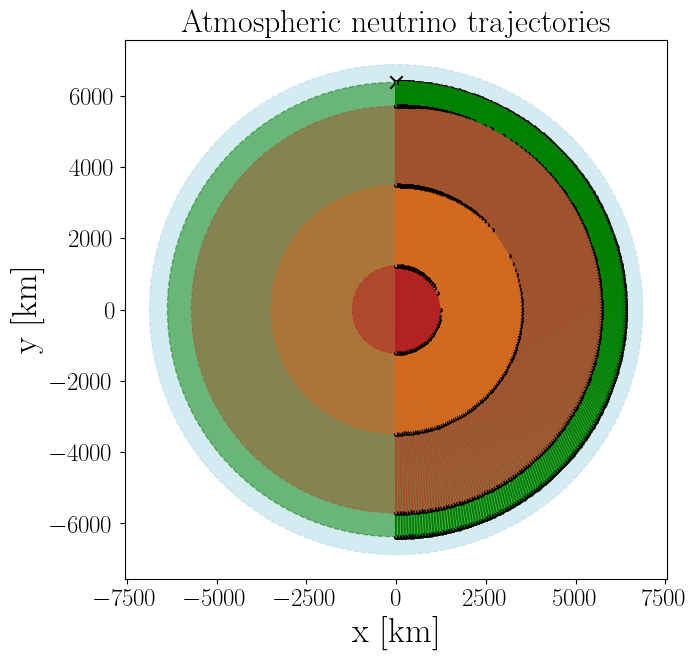

In [3]:
# Check slabs and trajectories
earth.plot_slabs(Thetaz)

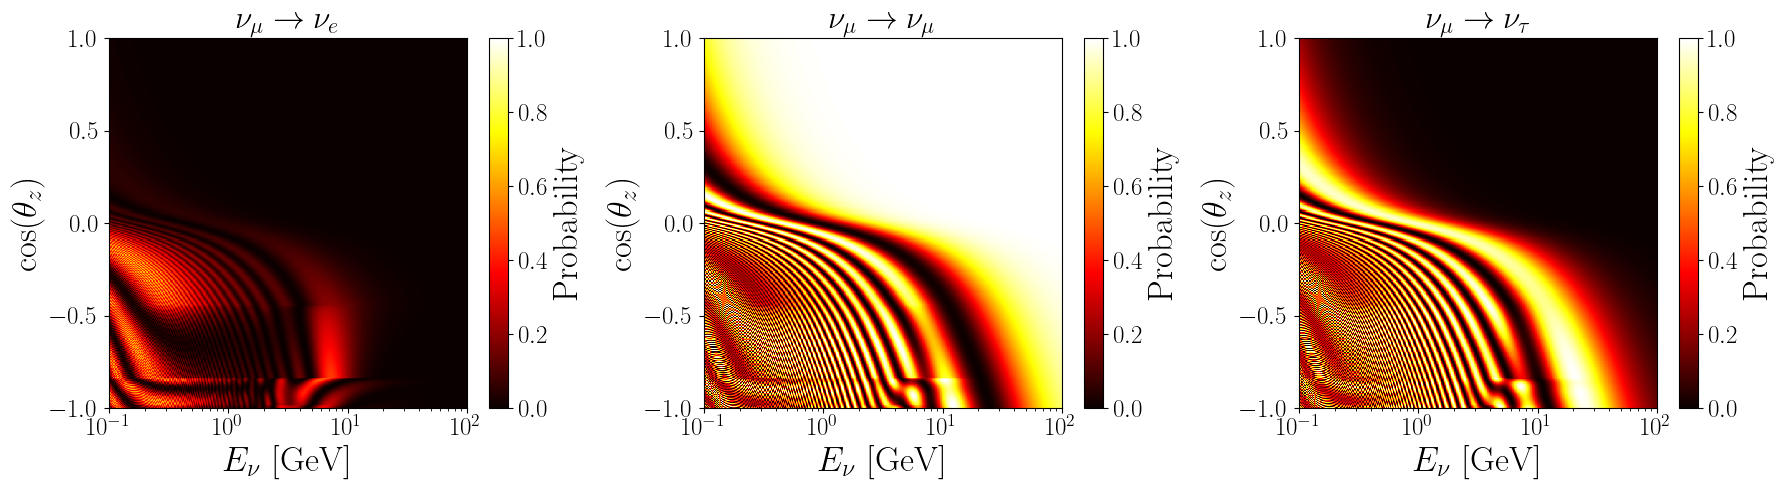

In [5]:
# Plot oscillograms
plot_oscillograms(Thetaz, E, P_mu, "mu", ["e", "mu", "tau"])